In [18]:
import pandas as pd
import numpy as np

# ============================================================
# 1. Load data
# ============================================================

file_path = r"C:\Users\amigo\Documents\GitHub\PlantingDates\Grids Germany\No leap years\Brandenburg.xlsx"

df = pd.read_excel(file_path)

# ============================================================
# 2. Variables used to define the 4-dimensional space
# ============================================================

variables = [
    "average_temp_c",
    "relative_humidity_%",
    "soil_temp_5cm_c",
    "soil_moisture_0-10cm_%"
]

# ============================================================
# 3. Reference centroid C*
# ============================================================

C_star = np.array([
    11.10,  # max_temp_c
    75.00,  # relative_humidity_%
    9.00,   # soil_temp_5cm_c
    85.00   # soil_moisture_0-10cm_%
])

# ============================================================
# 4. Calculate centroid and distances for each DOY
# ============================================================

results = []

for doy in range(1, 366):

    # --------------------------------------------------------
    # Select the 30 observations corresponding to this DOY
    # --------------------------------------------------------
    doy_data = df.loc[df["DOY"] == doy, variables]

    # Check that exactly 30 observations are available
    if len(doy_data) != 30:
        print(
            f"Warning: DOY {doy} contains "
            f"{len(doy_data)} observations instead of 30."
        )

    # --------------------------------------------------------
    # Convert to NumPy array
    # --------------------------------------------------------
    X = doy_data.to_numpy(dtype=float)

    # --------------------------------------------------------
    # Calculate the 4-dimensional centroid
    # --------------------------------------------------------
    centroid = np.mean(X, axis=0)

    # --------------------------------------------------------
    # Euclidean distance
    # --------------------------------------------------------
    euclidean_distance = np.linalg.norm(
        centroid - C_star
    )

    # --------------------------------------------------------
    # Manhattan distance
    # --------------------------------------------------------
    manhattan_distance = np.sum(
        np.abs(centroid - C_star)
    )

    # --------------------------------------------------------
    # Store results
    # --------------------------------------------------------
    results.append({
        "DOY": doy,

        "centroid__temp_c": centroid[0],
        "centroid_relative_humidity_%": centroid[1],
        "centroid_soil_temp_5cm_c": centroid[2],
        "centroid_soil_moisture_0-10cm_%": centroid[3],

        "euclidean_distance": euclidean_distance,
        "manhattan_distance": manhattan_distance
    })

# ============================================================
# 5. Convert results to DataFrame
# ============================================================

distance_df = pd.DataFrame(results)

# ============================================================
# 6. Extract the distance vectors
# ============================================================

euclidean_vector = distance_df["euclidean_distance"].to_numpy()

manhattan_vector = distance_df["manhattan_distance"].to_numpy()

# ============================================================
# 7. Display results
# ============================================================

print(distance_df)

print("\nEuclidean distance vector:")
print(euclidean_vector)

print("\nManhattan distance vector:")
print(manhattan_vector)

     DOY  centroid__temp_c  centroid_relative_humidity_%  \
0      1          1.814832                     86.138713   
1      2          1.579009                     86.023607   
2      3          1.200626                     86.022269   
3      4          1.032182                     85.708881   
4      5          0.347315                     85.708098   
..   ...               ...                           ...   
360  361          1.825011                     86.571037   
361  362          1.356019                     86.525065   
362  363          1.230633                     87.510461   
363  364          0.809811                     86.035187   
364  365          1.653756                     85.669494   

     centroid_soil_temp_5cm_c  centroid_soil_moisture_0-10cm_%  \
0                    1.580531                       101.804173   
1                    1.307761                       104.470235   
2                    1.239862                       106.999871   
3              

In [19]:
euclidean_vector_normalized = (
    euclidean_vector / np.max(euclidean_vector)
)

manhattan_vector_normalized = (
    manhattan_vector / np.max(manhattan_vector)
)

In [20]:
euclidean_vector_complement = 1 - euclidean_vector_normalized

manhattan_vector_complement = 1 - manhattan_vector_normalized

In [21]:
print(euclidean_vector_complement)

print(manhattan_vector_complement)

print(np.max(euclidean_vector_complement))
print(np.max(manhattan_vector_complement))

[0.57856485 0.54074484 0.50235939 0.48945425 0.47555664 0.46476813
 0.47215121 0.46198832 0.43534691 0.49240534 0.48122429 0.50519458
 0.50888923 0.54077456 0.55899834 0.55952225 0.5652895  0.50932777
 0.49619154 0.45966163 0.49477648 0.52791417 0.52297692 0.53282213
 0.57051738 0.53702688 0.5442065  0.52585783 0.52984763 0.51087436
 0.53537739 0.54814795 0.53117408 0.49428755 0.53285849 0.55777934
 0.58012858 0.60035311 0.59618187 0.5959822  0.57206358 0.57846027
 0.59221935 0.58432636 0.62134576 0.64605616 0.63523043 0.61797649
 0.60152232 0.59665759 0.62213061 0.62065249 0.59775227 0.58604242
 0.63495103 0.64586165 0.63608666 0.69557305 0.71082791 0.67889785
 0.67977245 0.70344791 0.73892857 0.76209688 0.73191569 0.7385153
 0.76508494 0.7389053  0.71765488 0.72177861 0.69448697 0.7477523
 0.69568353 0.73408875 0.75854985 0.78076234 0.7981019  0.76825103
 0.79509796 0.76230143 0.78099078 0.7877706  0.82735399 0.84767991
 0.87348913 0.87816696 0.88435008 0.88009517 0.90535442 0.900953

In [22]:
np.sum(manhattan_vector_complement > 0.7)

70

In [23]:
indices = np.where(manhattan_vector_complement > 0.7)[0]

print(indices)

[ 63  66  71  74  75  76  77  78  79  80  81  82  83  84  85  86  87  88
  89  90  91  92  93  94  95  96  97  98  99 100 101 102 103 104 105 106
 107 108 126 277 278 279 280 281 282 283 284 285 286 287 288 289 290 291
 292 293 294 295 296 297 298 299 300 301 302 303 304 305 306 309]


In [24]:
import numpy as np


def random_walking(probabilities, starting_position, emergence_threshold, rng=None):
    """
    Simulate a circular random walk with an emergence threshold.

    Parameters
    ----------
    probabilities : array-like
        Vector of transition success probabilities (values between 0 and 1).

    starting_position : int
        Initial position of the walker (1, ..., n).

    emergence_threshold : int
        Path length at which emergence is recorded.

    rng : numpy.random.Generator, optional
        Random number generator used to generate independent Uniform(0,1)
        random variables. If omitted, a NumPy default random number
        generator is created automatically.

    Returns
    -------
    path_length : int
        Total number of successful moves before termination.

    outcome : str
        Termination condition: 'failure' or 'return'.

    emerged : bool
        True if the emergence threshold was reached.

    emergence_position : int or None
        Position where emergence occurred.

    emergence_time : int or None
        Path length when emergence occurred.

    path : list
        Sequence of visited positions.
    """

    n = len(probabilities)

    if not (1 <= starting_position <= n):
        raise ValueError(
            f"'starting_position' must be between 1 and {n}."
        )

    if not (1 <= emergence_threshold <= n):
        raise ValueError(
            f"'emergence_threshold' must be between 1 and {n}."
        )

    if rng is None:
        rng = np.random.default_rng()

    start = starting_position - 1
    position = start

    path_length = 0
    path = [starting_position]

    emerged = False
    emergence_position = None
    emergence_time = None

    while True:

        u = rng.random()

        # Successful transition
        if u <= probabilities[position]:

            path_length += 1
            position = (position + 1) % n

            path.append(position + 1)

            # Record emergence only once
            if (not emerged) and (path_length >= emergence_threshold):
                emerged = True
                emergence_position = position + 1
                emergence_time = path_length

            # Stop if returned to initial position
            if position == start:

                if emerged:
                    return (
                        emerged,
                        path_length,
                        "emerged_return",
                        emergence_position,
                        emergence_time,
                        path
                    )
                else:
                    return (
                        emerged,
                        path_length,
                        "return",
                        emergence_position,
                        emergence_time,
                        path
                    )

        # Failed transition
        else:

            if emerged:
                emergence_position = position + 1
                return (
                    emerged,
                    path_length,
                    "emerged_failure",
                    emergence_position,
                    emergence_time,
                    path
                )
            else:
                return (
                    emerged,
                    path_length,
                    "failure",
                    None,
                    None,
                    path
                )

In [25]:
rng = np.random.default_rng()

probabilities=euclidean_vector_complement

result = random_walking(
    probabilities=probabilities,
    starting_position=98,
    emergence_threshold=2,
    rng=rng
)

print(result)

(True, 8, 'emerged_failure', 106, 2, [98, 99, 100, 101, 102, 103, 104, 105, 106])


In [26]:
rng = np.random.default_rng()

probabilities = euclidean_vector_complement
starting_position = 99
emergence_threshold = 13

results = []

for _ in range(5000):

    emerged, path_length, outcome, emerged_position, emerged_time, path = random_walking(
        probabilities=probabilities,
        starting_position=starting_position,
        emergence_threshold=emergence_threshold,
        rng=rng
    )

    results.append(
        {
            "path_length": path_length,
            "outcome": outcome,
            "emerged": emerged,
            "emerged_position": emerged_position,
            "emerged_time": emerged_time,
            "path": path
        }
    )

emergence_probability = (
    sum(r["emerged"] for r in results)
    / len(results)
)

print(emergence_probability)

0.1098


In [27]:
path[-1]

114

In [28]:
finalpos = [
    r["path"][-1]
    for r in results
]

In [29]:
ci = np.quantile(
    finalpos,
    [0.025, 0.975],
    method="nearest"
)

print(ci)

[ 99 115]


In [30]:
lengths = [
    r["path_length"]
    for r in results
]

In [31]:
ci_2 = np.quantile(
    lengths,
    [0.025, 0.975],
    method="nearest"
)

print(ci_2)

[ 0 16]


In [32]:
np.quantile(
    lengths,
    [0,.99])

array([ 0., 19.])

In [33]:
#emergence_positions = [
#    r["emerged_position"]
#    for r in results
#    if r["emerged"]
#]

ci = np.quantile(
    emergence_positions,
    [0.025, 0.975],
    method="nearest"
)

#emergence_lengths = [
#    r["path_length"]
#    for r in results
#    if r["emerged"]
#]

ci_2 = np.quantile(
    emergence_lengths,
    [0.025, 0.975],
    method="nearest"
)

NameError: name 'emergence_positions' is not defined

In [ ]:
print(ci_2)

In [ ]:
print(ci)

In [ ]:
emergence_lengths

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

# -----------------------------
# Probabilidades
# -----------------------------
p = euclidean_vector_complement

# -----------------------------
# Ángulos: 365 segmentos
# -----------------------------
n = 365
theta = np.linspace(0, 2*np.pi, n, endpoint=False)
width = 2*np.pi / n

# -----------------------------
# Colormap personalizado
# -----------------------------
cmap = LinearSegmentedColormap.from_list(
    "probability",
    [
        (0.00, "blue"),
        (0.15, "blue"),
        (0.70, "green"),
        (1.00, "green")
    ]
)

# Colores correspondientes a cada probabilidad
colors = cmap(p)

# -----------------------------
# Gráfica polar
# -----------------------------
fig, ax = plt.subplots(
    figsize=(8, 8),
    subplot_kw={"projection": "polar"}
)

ax.bar(
    theta,
    np.ones(n),
    width=width,
    bottom=0.0,
    color=colors,
    edgecolor="none",
    align="edge"
)

# -----------------------------
# Orientación
# -----------------------------
ax.set_theta_zero_location("W")   # Día 1 arriba
ax.set_theta_direction(-1)        # sentido horario

# -----------------------------
# Apariencia
# -----------------------------
ax.set_ylim(0, 1)
ax.set_yticks([])
ax.set_xticks([])

ax.spines["polar"].set_visible(False)

plt.show()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

# ============================================================
# Probabilidades
# ============================================================

p = euclidean_vector_complement

n = 365

# ============================================================
# Ángulos
# ============================================================

theta = np.linspace(0, 2 * np.pi, n, endpoint=False)
width = 2 * np.pi / n

# ============================================================
# Degradado rojo -> naranja -> verde
# ============================================================

cmap = LinearSegmentedColormap.from_list(
    "probability",
    [
        (0.00, "#d73027"),   # rojo
        (0.69, "#fdae61"),   # naranja
        (0.70, "#1a9850"),    # verde
        (1.00, "#1a9850")    # verde
    ]
)

colors = cmap(p)

# ============================================================
# Figura
# ============================================================

fig, ax = plt.subplots(
    figsize=(9, 9),
    subplot_kw={"projection": "polar"}
)

# ============================================================
# Anillo de 365 días
# ============================================================

ax.bar(
    theta,
    np.ones(n),
    width=width,
    bottom=0.70,
    color=colors,
    edgecolor="none",
    align="edge"
)

# ============================================================
# Orientación
# ============================================================

ax.set_theta_zero_location("W")
ax.set_theta_direction(1)

# ============================================================
# Límites y apariencia
# ============================================================

ax.set_ylim(0.70, 1.00)

ax.set_yticks([])
ax.set_xticks([])

ax.spines["polar"].set_visible(False)

# ============================================================
# Límites de los meses
# ============================================================

month_starts = [
    1,    # Jan
    32,   # Feb
    60,   # Mar
    91,   # Apr
    121,  # May
    152,  # Jun
    182,  # Jul
    213,  # Aug
    244,  # Sep
    274,  # Oct
    305,  # Nov
    335   # Dec
]

month_names = [
    "Jan", "Feb", "Mar", "Apr", "May", "Jun",
    "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"
]

for day, month in zip(month_starts, month_names):

    angle = 2 * np.pi * (day-1) / 365

    # Línea divisoria
    ax.plot(
        [angle, angle],
        [0.70, 1.00],
        linewidth=1.2,
        color="black",
        alpha=0.7
    )

    # Nombre del mes
    ax.text(
        angle+0.26,
        1.03,
        month,
        ha="center",
        va="center",
        fontsize=11
    )

plt.show()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap, Normalize

# ============================================================
# Probabilidades
# ============================================================

p = np.asarray(euclidean_vector_complement)

n = 365

# ============================================================
# Degradado rojo -> naranja -> verde
# ============================================================

cmap = LinearSegmentedColormap.from_list(
    "probability",
    [
        (0.00, "#8b1a1a"),   # rojo oscuro
        (0.40, "#d95f4f"),   # naranja rojizo
        (0.70, "#f6c27a"),   # mantener naranja
        (0.70, "#6fae72"),   # verde suave en el umbral
        (0.85, "#238b45"),   # verde
        (1.00, "#0f8a3b")    # verde oscuro
    ]
)

norm = Normalize(vmin=0, vmax=1)

colors = cmap(norm(p))

# ============================================================
# Figura
# ============================================================

fig, ax = plt.subplots(figsize=(9, 9))

# ============================================================
# Donut: 365 segmentos de igual tamaño
# ============================================================

ax.pie(
    np.ones(n),
    colors=colors,
    startangle=180,
    counterclock=True,
    wedgeprops={
        "width": 0.30,
        "edgecolor": "none"
    }
)

# ============================================================
# Ticks cada 50 días
# ============================================================

tick_days = list(np.arange(0, 351, 50))

for day in tick_days:

    angle = np.deg2rad(
        180 + (day) * 360 / 365
    )

    # Línea del tick
    ax.plot(
        [np.cos(angle) * 0.68, np.cos(angle) * 0.7],
        [np.sin(angle) * 0.68, np.sin(angle) * 0.7],
        color="black",
        linewidth=1.2
    )
    
    if day == 0:
        day=day+1

    # Etiqueta
    ax.text(
        np.cos(angle) * 0.62,
        np.sin(angle) * 0.62,
        str(day),
        ha="center",
        va="center",
        fontsize=9
    )

# ============================================================
# Límites de los meses
# ============================================================

month_starts = [
    1, 32, 60, 91, 121, 152,
    182, 213, 244, 274, 305, 335
]

month_names = [
    "Jan", "Feb", "Mar", "Apr", "May", "Jun",
    "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"
]

# Ángulo de cada día
# 0° = derecha; 90° = arriba
def day_to_angle(day):
    return 180 + (day - 1) * 360 / 365


# ============================================================
# Líneas divisorias de los meses
# ============================================================

for day in month_starts:

    angle = np.deg2rad(day_to_angle(day))

    ax.plot(
        [np.cos(angle) * 0.70, np.cos(angle)],
        [np.sin(angle) * 0.70, np.sin(angle)],
        color="black",
        linewidth=1.2,
        alpha=0.8
    )


# ============================================================
# Etiquetas de los meses
# ============================================================

# Día central aproximado de cada mes
month_midpoints = [
    16, 46, 75, 106, 136, 167,
    197, 228, 259, 289, 320, 350
]

for day, month in zip(month_midpoints, month_names):

    angle = np.deg2rad(day_to_angle(day))

    ax.text(
        np.cos(angle) * 1.07,
        np.sin(angle) * 1.07,
        month,
        ha="center",
        va="center",
        fontsize=11
    )


# ============================================================
# Apariencia
# ============================================================

ax.set_aspect("equal")
ax.axis("off")
# ============================================================
# Barra de escala de colores
# ============================================================

norm = plt.Normalize(vmin=0, vmax=1)

sm = plt.cm.ScalarMappable(
    cmap=cmap,
    norm=norm
)

sm.set_array([])

cbar = fig.colorbar(
    sm,
    ax=ax,
    orientation="horizontal",
    fraction=0.045,
    pad=0.08
)

cbar.set_label(
    "Probability",
    fontsize=11
)

cbar.set_ticks([0, 0.20, 0.40, 0.60, 0.80, 1.00])

cbar.ax.set_xticklabels([
    "0",
    "0.20",
    "0.40",
    "0.60",
    "0.80",
    "1"
])
plt.show()

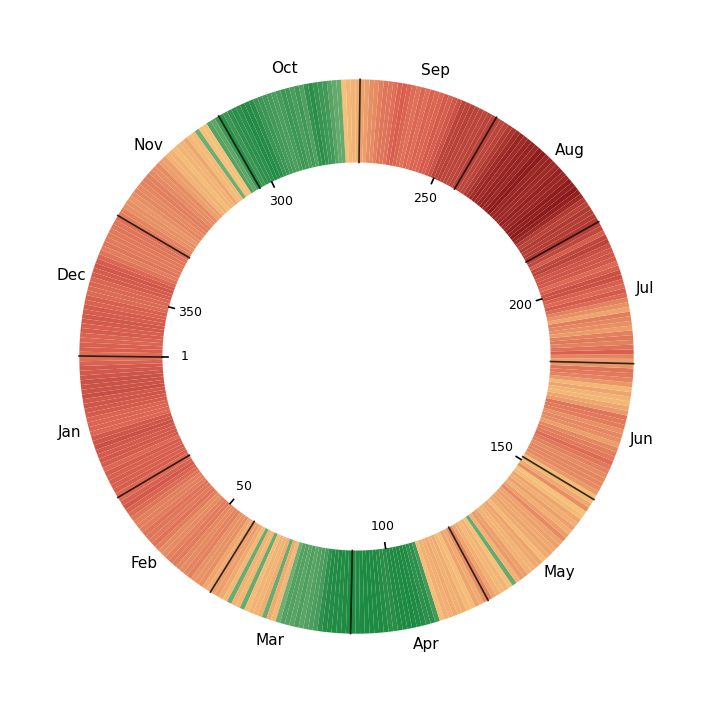

In [34]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap, Normalize

# ============================================================
# Probabilidades
# ============================================================

p = np.asarray(manhattan_vector_complement)

n = 365

# ============================================================
# Degradado rojo -> naranja -> verde
# ============================================================

cmap = LinearSegmentedColormap.from_list(
    "probability",
    [
        (0.00, "#8b1a1a"),   # rojo oscuro
        (0.40, "#d95f4f"),   # naranja rojizo
        (0.70, "#f6c27a"),   # mantener naranja
        (0.70, "#6fae72"),   # verde suave en el umbral
        (0.85, "#238b45"),   # verde
        (1.00, "#0f8a3b")    # verde oscuro
    ]
)

norm = Normalize(vmin=0, vmax=1)

colors = cmap(norm(p))

# ============================================================
# Figura
# ============================================================

fig, ax = plt.subplots(figsize=(9, 9))

# ============================================================
# Donut: 365 segmentos de igual tamaño
# ============================================================

ax.pie(
    np.ones(n),
    colors=colors,
    startangle=180,
    counterclock=True,
    wedgeprops={
        "width": 0.30,
        "edgecolor": "none"
    }
)

# ============================================================
# Ticks cada 50 días
# ============================================================

tick_days = list(np.arange(0, 351, 50))

for day in tick_days:

    angle = np.deg2rad(
        180 + (day) * 360 / 365
    )

    # Línea del tick
    ax.plot(
        [np.cos(angle) * 0.68, np.cos(angle) * 0.7],
        [np.sin(angle) * 0.68, np.sin(angle) * 0.7],
        color="black",
        linewidth=1.2
    )
    
    if day == 0:
        day=day+1

    # Etiqueta
    ax.text(
        np.cos(angle) * 0.62,
        np.sin(angle) * 0.62,
        str(day),
        ha="center",
        va="center",
        fontsize=9
    )

# ============================================================
# Límites de los meses
# ============================================================

month_starts = [
    1, 32, 60, 91, 121, 152,
    182, 213, 244, 274, 305, 335
]

month_names = [
    "Jan", "Feb", "Mar", "Apr", "May", "Jun",
    "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"
]

# Ángulo de cada día
# 0° = derecha; 90° = arriba
def day_to_angle(day):
    return 180 + (day - 1) * 360 / 365


# ============================================================
# Líneas divisorias de los meses
# ============================================================

for day in month_starts:

    angle = np.deg2rad(day_to_angle(day))

    ax.plot(
        [np.cos(angle) * 0.70, np.cos(angle)],
        [np.sin(angle) * 0.70, np.sin(angle)],
        color="black",
        linewidth=1.2,
        alpha=0.8
    )


# ============================================================
# Etiquetas de los meses
# ============================================================

# Día central aproximado de cada mes
month_midpoints = [
    16, 46, 75, 106, 136, 167,
    197, 228, 259, 289, 320, 350
]

for day, month in zip(month_midpoints, month_names):

    angle = np.deg2rad(day_to_angle(day))

    ax.text(
        np.cos(angle) * 1.07,
        np.sin(angle) * 1.07,
        month,
        ha="center",
        va="center",
        fontsize=11
    )


# ============================================================
# Apariencia
# ============================================================

ax.set_aspect("equal")
ax.axis("off")
plt.savefig(
    "Brandenburg_Manhattan.png",
    dpi=300,
    bbox_inches="tight",
    pad_inches=0
)
plt.show()